In [1]:
library(gganatogram)
library(tidyverse)
library(Seurat)


Loading required package: ggpolypath

Loading required package: ggplot2

Warning message:
“package ‘purrr’ was built under R version 4.4.1”
Warning message:
“package ‘lubridate’ was built under R version 4.4.1”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.4     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
“package ‘Seurat’ was built under R version 4.4.1”
Loading required package: SeuratObject

Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.4.1”
‘SeuratObject’ was built with package ‘Matrix’ 1.7.0 but the current
version is 1.7.3;

In [2]:
meta <- read_csv('/Users/kylekimler/Projects/GCA/meta_datasets/gca_concatenated_metadata_343_March19_2025.csv')

New names:
• `` -> `...1`
Rows: 3381939 Columns: 55
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (52): ...1, dataset_id, donor_id, sample_id, author_cell_type, tissue_on...
dbl  (2): sample_collection_year, age_at_biopsy
lgl  (1): is_primary_data

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [83]:
atlas_tissues <- meta$tissue_ontology_term %>% unique

In [9]:
anatogram_tissues <- hgFemale_key %>% filter(type=='digestion') %>% pull(organ) %>% unique
anatogram_tissues

[1] "trachea"                   "tonsil"                   
 [3] "pancreas"                  "liver"                    
 [5] "colon"                     "urinary_bladder"          
 [7] "stomach"                   "duodenum"                 
 [9] "esophagus"                 "gall_bladder"             
[11] "spleen"                    "small_intestine"          
[13] "gastroesophageal_junction" "caecum"                   
[15] "ileum"                     "throat"                   
[17] "rectum"                    "kidney"                   
[19] "renal_cortex"

In [15]:
hgFemale_key %>% pull(organ) %>% unique

[1] "atrial_appendage"          "ectocervix"               
 [3] "hippocampus"               "pleura"                   
 [5] "bronchus"                  "trachea"                  
 [7] "lung"                      "tonsil"                   
 [9] "submandibular_gland"       "breast"                   
[11] "spinal_cord"               "pancreas"                 
[13] "liver"                     "colon"                    
[15] "bone_marrow"               "urinary_bladder"          
[17] "stomach"                   "duodenum"                 
[19] "esophagus"                 "gall_bladder"             
[21] "spleen"                    "small_intestine"          
[23] "placenta"                  "endometrium"              
[25] "vagina"                    "aorta"                    
[27] "pituitary_gland"           "gastroesophageal_junction"
[29] "caecum"                    "appendix"                 
[31] "ileum"                     "left_atrium"              
[33] "left_ventricle"            "pulmonary_valve"          
[35] "mitral_valve"              "diaphragm"                
[37] "bone"                      "cartilage"                
[39] "throat"                    "rectum"                   
[41] "nasal_septum"              "nasal_pharynx"            
[43] "cerebellum"                "cerebellar_hemisphere"    
[45] "prefrontal_cortex"         "frontal_cortex"           
[47] "nose"                      "temporal_lobe"            
[49] "cerebral_cortex"           "kidney"                   
[51] "renal_cortex"              "coronary_artery"          
[53] "tricuspid_valve"           "thyroid_gland"            
[55] "skin"                      "parotid_gland"            
[57] "adipose_tissue"            "heart"                    
[59] "smooth_muscle"             "brain"                    
[61] "adrenal_gland"             "lymph_node"               
[63] "skeletal_muscle"           "ovary"                    
[65] "leukocyte"                 "salivary_gland"           
[67] "fallopian_tube"            "uterus"                   
[69] "uterine_cervix"            "nerve"

In [28]:
setdiff(atlas_tissues, anatogram_tissues)

[1] "ascending_colon"                   "descending_colon"                 
[3] "gastrointestinal_system_mesentery" "jejunum"                          
[5] "sigmoid_colon"                     "transverse_colon"                 
[7] "vermiform_appendix"                NA

In [101]:

tissue_countsF <- meta %>% mutate(organ = case_when(
                tissue_ontology_term %in% c('ascending_colon', 'descending_colon', 'sigmoid_colon', 'transverse_colon') ~ 'colon',
                tissue_ontology_term %in% c('jejunum') ~ 'small_intestine',
                tissue_ontology_term %in% c('vermiform_appendix') ~ 'appendix',
                # tissue_ontology_term %in% c('gastrointestinal_system_mesentery') ~ 'lymph_node',
                .default = tissue_ontology_term
                )) %>%
                filter(sex_ontology_term == 'female') %>% 
                filter(!is.na(organ)) %>% 
                count(organ) %>% 
                mutate(atlas_composition = n/sum(n)) 


tissue_countsM <- meta %>% mutate(organ = case_when(
                tissue_ontology_term %in% c('ascending_colon', 'descending_colon', 'sigmoid_colon', 'transverse_colon') ~ 'colon',
                tissue_ontology_term %in% c('jejunum') ~ 'small_intestine',
                tissue_ontology_term %in% c('vermiform_appendix') ~ 'appendix',
                # tissue_ontology_term %in% c('gastrointestinal_system_mesentery') ~ 'lymph_node',
                .default = tissue_ontology_term
                )) %>%
                filter(sex_ontology_term == 'male') %>% 
                filter(!is.na(organ)) %>% 
                count(organ) %>% 
                mutate(atlas_composition = n/sum(n)) 




In [106]:
organ_removal = c('trachea', 'urinary_bladder', 'kidney', 'renal_cortex', 'spleen')


In [110]:

atlasF <- gganatogram(data=hgFemale_key %>% left_join(tissue_countsF) %>% 
                                  filter(type=='digestion') %>%
                                  distinct %>% 
                                  mutate(value = ifelse(is.na(atlas_composition), 0, atlas_composition)) %>%
                                  filter(!(organ %in% organ_removal)), 
                                  organism='human', 
                                  sex='female', fill="value") + 
                                  scale_fill_distiller(palette='Spectral') + 
                                  guides(fill = guide_legend(title='atlas\ncomposition')) +
                                  theme_void() + 
                                  ggtitle('Gut Cell Atlas Tissue Composition')

atlasM <- gganatogram(data=hgMale_key %>% left_join(tissue_countsM) %>% 
                                  filter(type=='digestion') %>%
                                  distinct %>% 
                                  mutate(value = ifelse(is.na(atlas_composition), 0, atlas_composition)) %>%
                                  filter(!(organ %in% organ_removal)), 
                                  organism='human', 
                                  sex='male', fill="value") + 
                                  scale_fill_distiller(palette='Spectral') + 
                                  guides(fill = guide_legend(title='atlas\ncomposition')) +
                                  theme_void()


Joining with `by = join_by(organ)`
Joining with `by = join_by(organ)`


Saving 7 x 7 in image


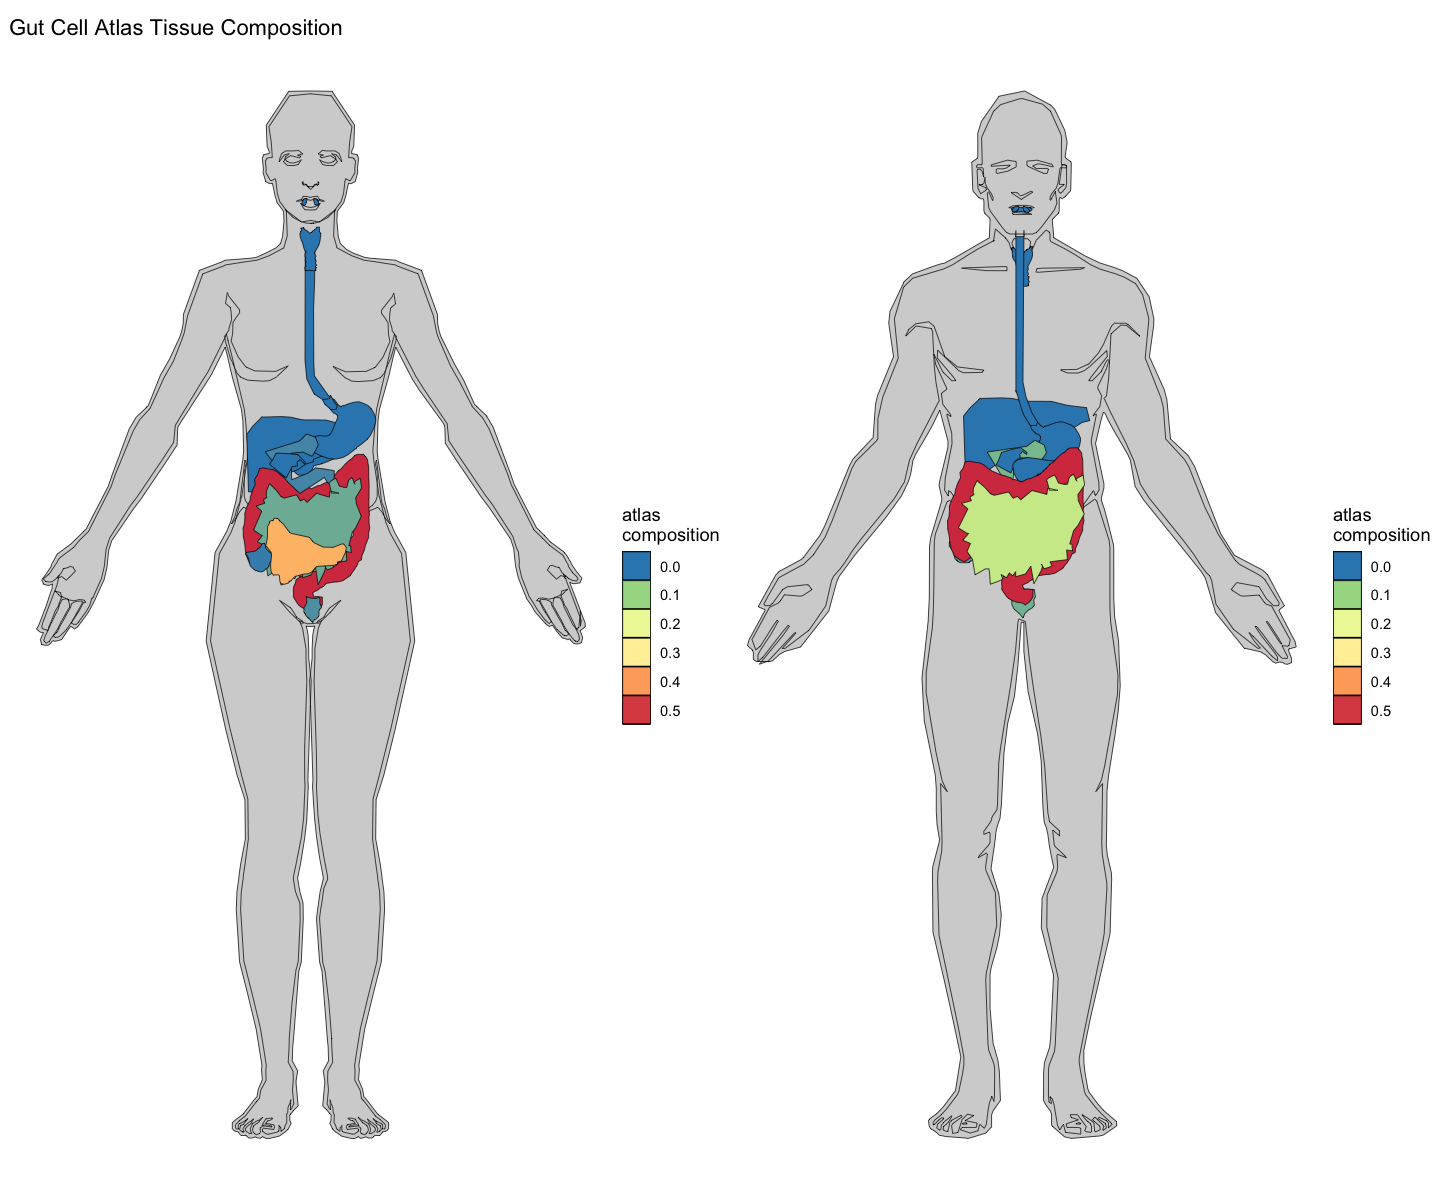

In [117]:
gut_atlas <- atlasF + atlasM
options(repr.plot.width=12, repr.plot.height=10)
gut_atlas
ggsave('~/Projects/GCA/graphics/anatogram_2025_March.png', gut_atlas)